# External Validation on INbreast

This notebook tests whether the four models selected in the main study (the baseline CNN and the winning configuration of each transfer-learning architecture, Section 6.4) generalise to an independent dataset: INbreast, full-field digital mammograms from a hospital in Portugal, never used for training, tuning or threshold selection.

**What is read from the main study** (all from Drive, nothing hardcoded):

| Item | Source file |
|---|---|
| The four selected models and preprocessing settings | `external_validation_config.json` (main notebook 6.4b) |
| Model checkpoints (3 seeds per model) | `search_log.jsonl`, `final_training_log.jsonl` |
| CBIS-DDSM test predictions and Youden thresholds | `final_predictions/*.npz` |
| CBIS-DDSM test metadata (lesion type, BI-RADS) | CBIS-DDSM zip (CSV files only) |

**Design.**
- **Frozen models.** Each model is scored as the mean probability of its three seed checkpoints, at the pooled CBIS-DDSM validation threshold, exactly as in the main study. Nothing is tuned on INbreast.
- **Proxy labels.** INbreast provides no pathology, so labels come from BI-RADS: 2 = benign, 4c/5/6 = malignant. BI-RADS 1/3/4a/4b are excluded.
- **Patient-level statistics.** CC and MLO views of the same breast show the same lesion, so confidence intervals come from a patient-level bootstrap.

**Sections.** 1 Setup · 2 INbreast data preparation · 3 CBIS-DDSM reference results · 4 Inference · 5 External performance · 6 Robustness checks · 7 Summary

## 1. Setup

Installs packages, mounts Drive, and loads the settings exported by the main notebook (Section 6.4b). `DRIVE_DIR` is the only path set by hand. Crop geometry constants are defined here because they come from the CBIS-DDSM crop analysis rather than from the main notebook's saved outputs.

In [ ]:
# =============================================================================
# 1. Setup
# =============================================================================
!pip install -q kaggle pydicom

import os, io, json, glob, zipfile, plistlib
from collections import Counter
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import tensorflow as tf
from PIL import Image
from skimage.draw import polygon
from sklearn.metrics import roc_auc_score, confusion_matrix, brier_score_loss
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess_input

from google.colab import drive
drive.mount("/content/drive")

# The only hand-set path: where the main notebook saves its outputs.
DRIVE_DIR = "/content/drive/MyDrive/random_search_full"

# Settings exported by the main notebook (6.4b): selected models, CLAHE settings, log paths
CONFIG_PATH = os.path.join(DRIVE_DIR, "external_validation_config.json")
assert os.path.exists(CONFIG_PATH), (
    f"{CONFIG_PATH} not found - run Section 6.4b in the main notebook first.")
with open(CONFIG_PATH) as f:
    MAIN = json.load(f)

# Baseline + one winner per architecture, and the exact CLAHE settings used in training
SELECTED_MODELS = MAIN["selected_models"]
DISPLAY = MAIN["display_names"]
CLAHE_CLIP_LIMIT = MAIN["clahe_clip_limit"]
CLAHE_TILE_GRID_SIZE = tuple(MAIN["clahe_tile_grid_size"])

# Frozen configs are head-only models trained on cached features, so they
# can't be run on raw images here.
for name in SELECTED_MODELS:
    assert MAIN["model_kinds"][name] != "frozen", (
        f"{name} is a frozen config; this notebook only supports end-to-end models.")

# Crop geometry, matched to CBIS-DDSM crops
CROP_PADDING = 1.10          # median crop-to-ROI ratio of CBIS-DDSM crops
MIN_CROP_SIZE = 100          # px, smallest crop side
CALC_CLUSTER_DISTANCE = 200  # px, max gap between calcifications in one cluster

# Statistics
RANDOM_SEED = 42
N_BOOTSTRAP = 2000

INBREAST_ROOT = "/content/INbreast Release 1.0"

print("Selected models:", [DISPLAY[n] for n in SELECTED_MODELS])
print(f"CLAHE: clip {CLAHE_CLIP_LIMIT}, tiles {CLAHE_TILE_GRID_SIZE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Selected models: ['Baseline CNN', 'VGG16 (Partial FT)', 'ResNet50 (Partial FT)', 'EfficientNetB0 (Partial FT)']
CLAHE: clip 2.0, tiles (8, 8)


## 2. INbreast Data Preparation

### 2.1 Download

Downloads INbreast from a Kaggle mirror (DICOM images, XML annotations, metadata spreadsheet). INbreast is officially distributed by its authors on request; see Methods Section 3.2.3.

In [ ]:
# =============================================================================
# 2.1 Download INbreast
# =============================================================================
# Kaggle mirror of INbreast: DICOM images, XML ROI annotations and INbreast.xls
!kaggle datasets download -d ramanathansp20/inbreast-dataset --unzip -p /content
print(os.listdir(INBREAST_ROOT))

Dataset URL: https://www.kaggle.com/datasets/ramanathansp20/inbreast-dataset
License(s): unknown
100% 1.93G/1.93G [01:51<00:00, 18.6MB/s]

['README.txt', 'inbreast.pdf', 'INbreast.csv', 'AllDICOMs', 'INbreast.xls', 'PectoralMuscle', 'MedicalReports', 'AllROI', 'AllXML']


### 2.2 Metadata Check

Confirms the extracted files match the documented layout (DICOM images, XML annotations, metadata spreadsheet) before any processing.

In [ ]:
# =============================================================================
# 2.2 Metadata Check
# =============================================================================

import os
import pandas as pd

# INbreast layout: images, ROI annotations, case-level spreadsheet
dicom_dir = os.path.join(INBREAST_ROOT, "AllDICOMs")
xml_dir   = os.path.join(INBREAST_ROOT, "AllXML")
xls_path  = os.path.join(INBREAST_ROOT, "INbreast.xls")

print("DICOM files:", len([f for f in os.listdir(dicom_dir) if f.endswith(".dcm")]))
print("XML files:  ", len([f for f in os.listdir(xml_dir) if f.endswith(".xml")]))

# One row per image: laterality, view, BI-RADS and lesion flags (Mass / Micros)
metadata = pd.read_excel(xls_path)
print(metadata.shape)
print(metadata.columns.tolist())
metadata.head(10)

DICOM files: 410
XML files:   343
(412, 17)
['Patient ID', 'Patient age', 'Laterality', 'View', 'Acquisition date', 'File Name', 'ACR', 'Bi-Rads', 'Mass ', 'Micros', 'Distortion', 'Asymmetry', 'Findings Notes (in Portuguese)', 'Other Notes', 'Lesion Annotation Status', 'Pectoral Muscle Annotation', 'Other Annotations']


,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads,Mass,Micros,Distortion,Asymmetry,Findings Notes (in Portuguese),Other Notes,Lesion Annotation Status,Pectoral Muscle Annotation,Other Annotations
0,removed,removed,R,CC,201001.0,22678622.0,4,1,NaN,NaN,NaN,NaN,normal,NaN,No annotation (Normal),NaN,NaN
1,removed,removed,L,CC,201001.0,22678646.0,4,3,X,NaN,NaN,NaN,nódulo,NaN,NaN,NaN,NaN
2,removed,removed,R,MLO,201001.0,22678670.0,4,1,NaN,NaN,NaN,NaN,normal,NaN,No annotation (Normal),NaN,NaN
3,removed,removed,L,MLO,201001.0,22678694.0,4,3,X,NaN,NaN,NaN,nódulo,NaN,NaN,NaN,NaN
4,removed,removed,R,CC,201001.0,22614074.0,2,5,X,X,NaN,NaN,nódulo QSE + micros,NaN,NaN,NaN,NaN
5,removed,removed,L,CC,201001.0,22614097.0,2,2,X,X,NaN,NaN,nodulo + micros,NaN,NaN,NaN,NaN
6,removed,removed,R,MLO,201001.0,22614127.0,2,5,X,X,NaN,NaN,nódulo QSE + micros,NaN,NaN,NaN,NaN
7,removed,removed,L,MLO,201001.0,22614150.0,2,2,X,X,NaN,NaN,nódulo + micros,NaN,NaN,NaN,NaN
8,removed,removed,L,MLO,201001.0,50997434.0,3,2,NaN,X,NaN,NaN,micro,NaN,NaN,NaN,NaN
9,removed,removed,R,MLO,201001.0,50997461.0,3,4a,X,X,NaN,NaN,nodulo QSE + micros,NaN,NaN,NaN,NaN


### 2.3 Label Availability

Checks whether the spreadsheet or its free-text notes contain biopsy or histology results.Only a few notes mention a benign diagnosis (e.g. one biopsied fibroadenoma, shown in two views); there is no systematic pathology, so labels are derived from BI-RADS instead (Section 2.7). The release also includes free-text medical reports in Portuguese; these were not systematically reviewed for histology.

In [ ]:
# =============================================================================
# 2.3a Spreadsheet Columns
# =============================================================================

# Show example values of every text column to see which labels are available
for col in metadata.columns:
    if metadata[col].dtype == object:
        uniques = metadata[col].dropna().unique()
        print(f"{col!r}: {uniques[:12]}")

'Patient ID': ['removed']
'Patient age': ['removed']
'Laterality': ['R' 'L']
'View': ['CC' 'MLO' 'FB']
'ACR': [4 2 3 1
 '                                                                                                                                                                                                 '
 28]
'Bi-Rads': [1 3 5 2 '4a' '4c' 6 '4b' 49]
'Mass ': ['X' 108]
'Micros': ['X' 308]
'Distortion': [' ' 'X' 3]
'Asymmetry': ['X' 14]
'Findings Notes (in Portuguese)': ['normal' 'nódulo' 'nódulo QSE + micros' 'nodulo + micros'
 'nódulo QSE  + micros' 'nódulo + micros ' 'micro' 'nodulo QSE + micros'
 'Nódulo + micros' 'nódulo +micros' 'nódulo benigno' 'nodulo benigno']
'Other Notes': [' ']
'Lesion Annotation Status': ['No annotation (Normal)' 'no annotation (normal)' 'Spiculated Region']
'Pectoral Muscle Annotation': ['not possible' '   ' 'without muscle']
'Other Annotations': ['exemplo de onde se deve encontrar microcalcificaçoes'
 'Artifact not annotated' 'Artifact no annotat

In [ ]:
# =============================================================================
# 2.3b Free-Text Notes and Missing File Names
# =============================================================================

# Portuguese and English terms that would indicate a pathology result
keywords = ["bióps", "biops", "histolog", "benign", "malign", "carcinom", "PAAF"]

for col in ["Findings Notes (in Portuguese)", "Other Notes"]:
    matches = metadata[col].dropna().astype(str)
    hits = matches[matches.str.contains("|".join(keywords), case=False, na=False)]
    print(f"\n{col}: {len(hits)} rows mention a biopsy/histology term")
    if len(hits) > 0:
        print(hits.head(10).tolist())

# Spreadsheet rows without a matching image file
print("\nRows with missing File Name:", metadata["File Name"].isna().sum())
print(metadata[metadata["File Name"].isna()])


Findings Notes (in Portuguese): 10 rows mention a biopsy/histology term
['nódulo benigno', 'nodulo benigno', 'nódulo QSE - já biopsado - fibroadenoma', 'nódulo QSE - já biopsado - fibroadenoma', 'calcificações benignas', 'calcificações benignas', 'cc direita - calcificações + nodulo benigno - follow up', 'nódulo QII, benigno + micros', 'nódulo QII, benigno + micros', 'distorção do estroma QSE  - benigna + micros']

Other Notes: 0 rows mention a biopsy/histology term

Rows with missing File Name: 2
    Patient ID Patient age Laterality View  Acquisition date  File Name  ACR  \
410        NaN         NaN        NaN  NaN               NaN        NaN  NaN   
411        NaN         NaN        NaN  NaN               NaN        NaN   28   

    Bi-Rads Mass  Micros Distortion Asymmetry Findings Notes (in Portuguese)  \
410     NaN   NaN    NaN        NaN       NaN                            NaN   
411      49   108    308          3        14                            NaN   

    Other Note

### 2.4 DICOM Loader

INbreast images are 14-bit DICOM, not 8-bit JPEG like CBIS-DDSM. The loader also corrects MONOCHROME1 images (where 0 = white) so all images share the same brightness convention.

File: 51049462_6f64793857feb5d0_MG_L_ML_ANON.dcm
Shape: (3328, 2560)
Dtype in file: uint16 | BitsStored: 16
PhotometricInterpretation: MONOCHROME2
Pixel range: 0.0 - 2355.0


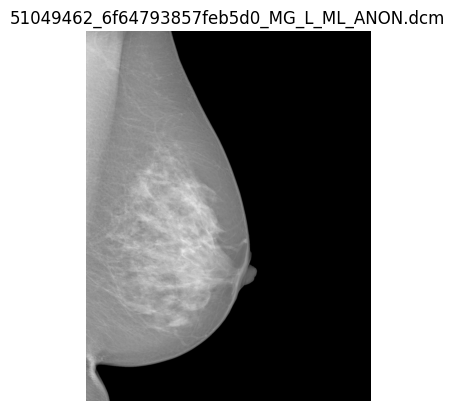

In [ ]:
# =============================================================================
# 2.4 DICOM Loader
# =============================================================================

import pydicom
import numpy as np

def load_inbreast_dicom(path):
    ds = pydicom.dcmread(path)
    # float32 keeps the full 14-bit range for later per-crop scaling
    pixels = ds.pixel_array.astype(np.float32)

    if ds.PhotometricInterpretation == "MONOCHROME1":
        # 0 = white in MONOCHROME1; invert so higher value = brighter,
        # matching MONOCHROME2 convention and CBIS-DDSM's crops.
        pixels = pixels.max() - pixels

    return pixels, ds

# Test on one file
test_file = os.listdir(dicom_dir)[0]
pixels, ds = load_inbreast_dicom(os.path.join(dicom_dir, test_file))

print("File:", test_file)
print("Shape:", pixels.shape)
print("Dtype in file:", ds.pixel_array.dtype, "| BitsStored:", ds.BitsStored)
print("PhotometricInterpretation:", ds.PhotometricInterpretation)
print("Pixel range:", pixels.min(), "-", pixels.max())

import matplotlib.pyplot as plt
plt.imshow(pixels, cmap="gray")
plt.title(test_file)
plt.axis("off")
plt.show()

### 2.5 ROI Parser

INbreast annotations are Apple property-list XML files. The parser returns a lesion mask and a bounding box per annotated region, tested here on one image.

ROIs found: [('Calcification', 1311.119995, 2360.879883, 1311.119995, 2360.879883), ('Calcification', 1151.790039, 1761.050049, 1151.790039, 1761.050049), ('Calcification', 648.98999, 1599.719971, 657.575989, 1610.449951), ('Calcification', 544.867981, 1582.359985, 544.867981, 1582.359985), ('Calcification', 681.698975, 1573.869995, 681.698975, 1573.869995), ('Calcification', 693.96698, 1556.880005, 693.96698, 1556.880005), ('Calcification', 656.219971, 1553.099976, 656.219971, 1553.099976), ('Calcification', 561.854004, 1388.910034, 561.854004, 1388.910034), ('Calcification', 512.783997, 261.230011, 512.783997, 261.230011), ('Calcification', 542.036987, 1234.150024, 542.036987, 1234.150024), ('Calcification', 231.865005, 1652.160034, 231.865005, 1652.160034), ('Calcification', 429.740997, 1649.359985, 429.740997, 1649.359985)]


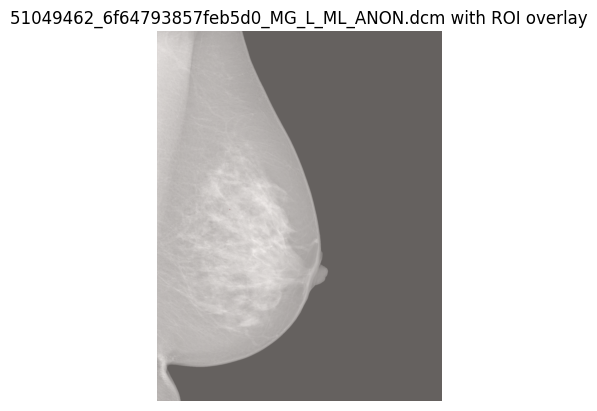

In [ ]:
# =============================================================================
# 2.5 ROI Parser
# =============================================================================

import plistlib
from skimage.draw import polygon

def load_inbreast_roi(xml_path, image_shape):
    with open(xml_path, "rb") as f:
        plist = plistlib.load(f)

    # All annotated ROIs of the image; each has a name and outline points
    rois = plist["Images"][0]["ROIs"]
    mask = np.zeros(image_shape, dtype=np.uint8)
    boxes = []  # (name, x_min, y_min, x_max, y_max) per ROI, for the crop step

    for roi in rois:
       # 'Point_px' stores points as strings such as '(x, y)'
        points = [
            tuple(float(v) for v in p.strip("()").split(","))
            for p in roi["Point_px"]
        ]
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        # Bounding box of the ROI, used later to place the crop
        boxes.append((roi.get("Name", "unknown"), min(xs), min(ys), max(xs), max(ys)))

        # Outline -> filled polygon; 1-2 points (single calcifications) -> marked pixels
        if len(points) > 2:
            rr, cc = polygon(ys, xs, shape=image_shape)
            mask[rr, cc] = 1
        else:
            for x, y in points:
                mask[int(y), int(x)] = 1

    return mask, boxes

# Overlay the ROI on the image loaded in 2.4
# XML files are named by the image ID (first part of the DICOM filename)
xml_test = test_file.split("_")[0] + ".xml"
mask, boxes = load_inbreast_roi(os.path.join(xml_dir, xml_test), pixels.shape)

print("ROIs found:", boxes)

plt.imshow(pixels, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.title(f"{test_file} with ROI overlay")
plt.axis("off")
plt.show()

### 2.6 ROI Name Audit

Lists every annotation name used in the XML files. The crop logic (Section 2.8) chooses its cropping method by name, so any unrecognised name must be checked here first.

In [ ]:
# =============================================================================
# 2.6 ROI Name Audit
# =============================================================================

from collections import Counter

# Count every ROI name across all XML files (names decide the crop rule in 2.8)
roi_name_counts = Counter()
for fname in os.listdir(xml_dir):
    if not fname.endswith(".xml"):
        continue
    with open(os.path.join(xml_dir, fname), "rb") as f:
        pl = plistlib.load(f)
    for roi in pl["Images"][0]["ROIs"]:
        roi_name_counts[str(roi.get("Name", "unknown")).strip()] += 1

for name, n in roi_name_counts.most_common():
    print(f"{n:6d}  {name!r}")

  7142  'Calcification'
   116  'Mass'
    27  'Cluster'
    14  'Spiculated Region'
     5  'Asymmetry'
     3  'Distortion'
     2  'Unnamed'
     1  'Calcifications'
     1  'Spiculated region'
     1  'Point 3'
     1  ''
     1  'Assymetry'
     1  'Point 1'
     1  'Espiculated Region'


### 2.7 Proxy Labels and Evaluation Set

| Label | BI-RADS | Meaning |
|---|---|---|
| Benign | 2 | Confidently benign |
| Malignant | 4c, 5, 6 | Highly suspicious or biopsy-proven |
| Excluded | 1, 3, 4a, 4b | No finding or uncertain |

Only images with an annotated mass or microcalcification are kept, and all eligible images are used. Patient IDs are taken from the DICOM filenames so that later statistics can resample by patient.

In [ ]:
# =============================================================================
# 2.7a Proxy Labels and Patient IDs
# =============================================================================

# Drop spreadsheet rows that have no image file
cases = metadata.dropna(subset=["File Name"]).copy()

# BI-RADS -> proxy label; uncertain categories return None and are excluded
def birads_proxy_label(b):
    b = str(b).strip()
    if b == "2":
        return "benign"
    if b in ("4c", "5", "6"):
        return "malignant"
    return None

cases["proxy_label"] = cases["Bi-Rads"].apply(birads_proxy_label)
# Keep only images flagged with a mass or microcalcifications ('X'); 'Mass ' has a trailing space in the file
has_lesion = (cases["Mass "] == "X") | (cases["Micros"] == "X")
candidates = cases[cases["proxy_label"].notna() & has_lesion].copy()

# Map image ID -> DICOM filename, then drop cases whose image is missing
dicom_lookup = {f.split("_")[0]: f for f in os.listdir(dicom_dir) if f.endswith(".dcm")}
candidates["dicom_filename"] = candidates["File Name"].apply(lambda x: dicom_lookup.get(str(int(x))))
candidates = candidates[candidates["dicom_filename"].notna()].copy()

# Patient ID = second part of the DICOM filename; breast = patient + side
candidates["patient"] = candidates["dicom_filename"].str.split("_").str[1]
candidates["breast"] = candidates["patient"] + "_" + candidates["Laterality"].astype(str)
candidates["Bi-Rads"] = candidates["Bi-Rads"].astype(str).str.strip()

# Patients with images in both classes (e.g. one benign breast, one malignant)
print(candidates["proxy_label"].value_counts())
print("\nUnique patients:", candidates["patient"].nunique())
print("Unique breasts: ", candidates["breast"].nunique())
print("\nBI-RADS breakdown:")
print(candidates.groupby(["proxy_label", "Bi-Rads"]).size())

# Patients with images in both classes (e.g. one benign breast, one malignant)
both = candidates.groupby("patient")["proxy_label"].nunique()
print("\nPatients with images in both classes:", int((both > 1).sum()))

proxy_label
benign       217
malignant     76
Name: count, dtype: int64

Unique patients: 88
Unique breasts:  139

BI-RADS breakdown:
proxy_label  Bi-Rads
benign       2          217
malignant    4c          19
             5           49
             6            8
dtype: int64

Patients with images in both classes: 26


In [ ]:
# =============================================================================
# 2.7b Evaluation Set
# =============================================================================

# All eligible images are used (no subsampling); saved so 2.8 can reload it
sample_cases = candidates.reset_index(drop=True)
sample_cases.to_csv("inbreast_eval_cases.csv", index=False)
print(sample_cases["proxy_label"].value_counts())
print("Saved to inbreast_eval_cases.csv")

proxy_label
benign       217
malignant     76
Name: count, dtype: int64
Saved to inbreast_eval_cases.csv


### 2.8 Crop Extraction

Each image is cropped around its annotated lesion, matching the CBIS-DDSM crop style: the largest mass if present, otherwise the largest annotated region, otherwise the largest calcification cluster. Padding and minimum size come from the setup constants. The 14-bit intensities are scaled to 8-bit per crop so the main study's preprocessing applies unchanged. Each crop records its ROI type for the shortcut checks in Section 6.

In [ ]:
# =============================================================================
# 2.8 Crop Extraction
# =============================================================================

# Read IDs as strings so they are not converted to numbers
sample_cases = pd.read_csv("inbreast_eval_cases.csv", dtype={"patient": str, "breast": str})

OUTPUT_DIR = "inbreast_crops"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ROI names (lower-case) treated as masses or regions; all other names are calcification points
MASS_ROI_NAMES = {"mass"}
REGION_ROI_NAMES = {"distortion", "asymmetry", "assymetry", "spiculated region",
                    "espiculated region", "cluster"}


def _norm(name):
    return str(name).strip().lower()

# Groups calcification centres: points within distance_threshold px are linked into one cluster
def cluster_points(centers, distance_threshold=200):
  # Groups calcification centres into clusters: any two points within
    # distance_threshold px are linked, and linked points form one cluste
    n = len(centers)
    visited = [False] * n
    clusters = []
    for i in range(n):
        if visited[i]:
            continue
        stack, cluster = [i], [i]  # start a new cluster from an unvisited point
        visited[i] = True
        while stack:
            cx, cy = centers[stack.pop()]
            for j in range(n):
                if not visited[j]:
                    x, y = centers[j]
                    # Euclidean distance; close points join the current cluster
                    if ((x - cx) ** 2 + (y - cy) ** 2) ** 0.5 <= distance_threshold:
                        visited[j] = True
                        stack.append(j)# its neighbours are checked next
                        cluster.append(j)
        clusters.append(cluster)
    return clusters

# Bounding box that encloses every ROI in a cluster
def cluster_bbox(cluster, boxes):
  # Bounding box (x_min, y_min, x_max, y_max) enclosing every ROI in the cluster;
    # each box is (name, x_min, y_min, x_max, y_max)
    return (min(boxes[i][1] for i in cluster), min(boxes[i][2] for i in cluster),
            max(boxes[i][3] for i in cluster), max(boxes[i][4] for i in cluster))


def _area(b):
   # Box area, used to pick the largest ROI
    return (b[3] - b[1]) * (b[4] - b[2])


def get_crop_box(boxes, padding_factor=CROP_PADDING, min_size=MIN_CROP_SIZE,
                 cluster_distance=CALC_CLUSTER_DISTANCE):
    """Returns (x0, y0, x1, y1, roi_type)."""
    mass_boxes = [b for b in boxes if _norm(b[0]) in MASS_ROI_NAMES]
    region_boxes = [b for b in boxes if _norm(b[0]) in REGION_ROI_NAMES]

    # Priority: largest mass > largest region > largest calcification cluster
    if mass_boxes:
        roi_type = "mass"
        _, x0, y0, x1, y1 = max(mass_boxes, key=_area)
    elif region_boxes:
        roi_type = "region"
        _, x0, y0, x1, y1 = max(region_boxes, key=_area)
    else:
        roi_type = "calc_points"
        # Centre of each calcification box, then group nearby centres
        centers = [((b[1] + b[3]) / 2, (b[2] + b[4]) / 2) for b in boxes]
        clusters = cluster_points(centers, distance_threshold=cluster_distance)
        # Largest cluster = most points, ties broken by cluster width
        largest = max(clusters, key=lambda c: (len(c), cluster_bbox(c, boxes)[2] - cluster_bbox(c, boxes)[0]))
        x0, y0, x1, y1 = cluster_bbox(largest, boxes)

    # Pad the box around its centre to match CBIS-DDSM crop tightness
    w, h = (x1 - x0) * padding_factor, (y1 - y0) * padding_factor
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    # Very small lesions get a MIN_CROP_SIZE square so the crop keeps some context
    if max(w, h) < min_size:
        w = h = min_size
    return cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2, roi_type


def normalise_to_8bit(pixels):
  # Min-max scale each crop to 0-255 (14-bit DICOM -> 8-bit, like CBIS-DDSM JPEGs)
    pixels = pixels - pixels.min()
    if pixels.max() > 0:# avoids division by zero on a uniform crop
        pixels = pixels / pixels.max()
    return (pixels * 255).astype(np.uint8)


manifest, skipped = [], [] # one entry per saved crop / per skipped image (with reason)

for _, row in sample_cases.iterrows():
    dicom_filename = row["dicom_filename"]

     # XML annotation file is named by the image ID (first part of the DICOM filename)
    xml_path = os.path.join(xml_dir, dicom_filename.split("_")[0] + ".xml")

    if not os.path.exists(xml_path):
        skipped.append({"dicom_filename": dicom_filename, "reason": "no matching XML file"})
        continue
    try:
        pixels, ds = load_inbreast_dicom(os.path.join(dicom_dir, dicom_filename))
        _, boxes = load_inbreast_roi(xml_path, pixels.shape) # only the bounding boxes are needed here
        if not boxes:
            skipped.append({"dicom_filename": dicom_filename, "reason": "XML had no ROIs"})
            continue

        x0, y0, x1, y1, roi_type = get_crop_box(boxes)
        # Clip the crop box to the image borders
        x0, y0 = max(0, int(x0)), max(0, int(y0))
        x1, y1 = min(pixels.shape[1], int(x1)), min(pixels.shape[0], int(y1))
        crop = pixels[y0:y1, x0:x1]
        if crop.size == 0:
            skipped.append({"dicom_filename": dicom_filename, "reason": "empty crop after clipping"})
            continue

         # Save as an RGB JPEG so the main study's image pipeline reads it unchanged
        out_path = os.path.join(OUTPUT_DIR, dicom_filename.replace(".dcm", ".jpg"))
        Image.fromarray(normalise_to_8bit(crop)).convert("RGB").save(out_path)

        # Label and patient/breast IDs (for the patient-level bootstrap),
        # ROI type and crop size (for the shortcut checks in Section 6)
        manifest.append({
            "dicom_filename": dicom_filename,
            "crop_path": out_path,
            "proxy_label": row["proxy_label"],
            "birads": row["Bi-Rads"],
            "patient": row["patient"],
            "breast": row["breast"],
            "view": row["View"],
            "roi_type": roi_type,
            "roi_names": ";".join(sorted({_norm(b[0]) for b in boxes})),
            "crop_width": crop.shape[1],
            "crop_height": crop.shape[0],
        })
    except Exception as e:
        # Record the failure and continue with the next image
        skipped.append({"dicom_filename": dicom_filename, "reason": str(e)})

manifest_df = pd.DataFrame(manifest)
skipped_df = pd.DataFrame(skipped)
manifest_df.to_csv("inbreast_manifest.csv", index=False) # evaluation set used by all later sections

print(f"Extracted: {len(manifest_df)} crops | Skipped: {len(skipped_df)}")
if len(skipped_df) > 0:
    print(skipped_df["reason"].value_counts())
print("\nFinal evaluation set:")
print(manifest_df["proxy_label"].value_counts())
print("Unique patients:", manifest_df["patient"].nunique())

Extracted: 293 crops | Skipped: 0

Final evaluation set:
proxy_label
benign       217
malignant     76
Name: count, dtype: int64
Unique patients: 88


### 2.9 Visual Quality Check

Three random crops per class and ROI type, to confirm the crops are centred on the lesion.

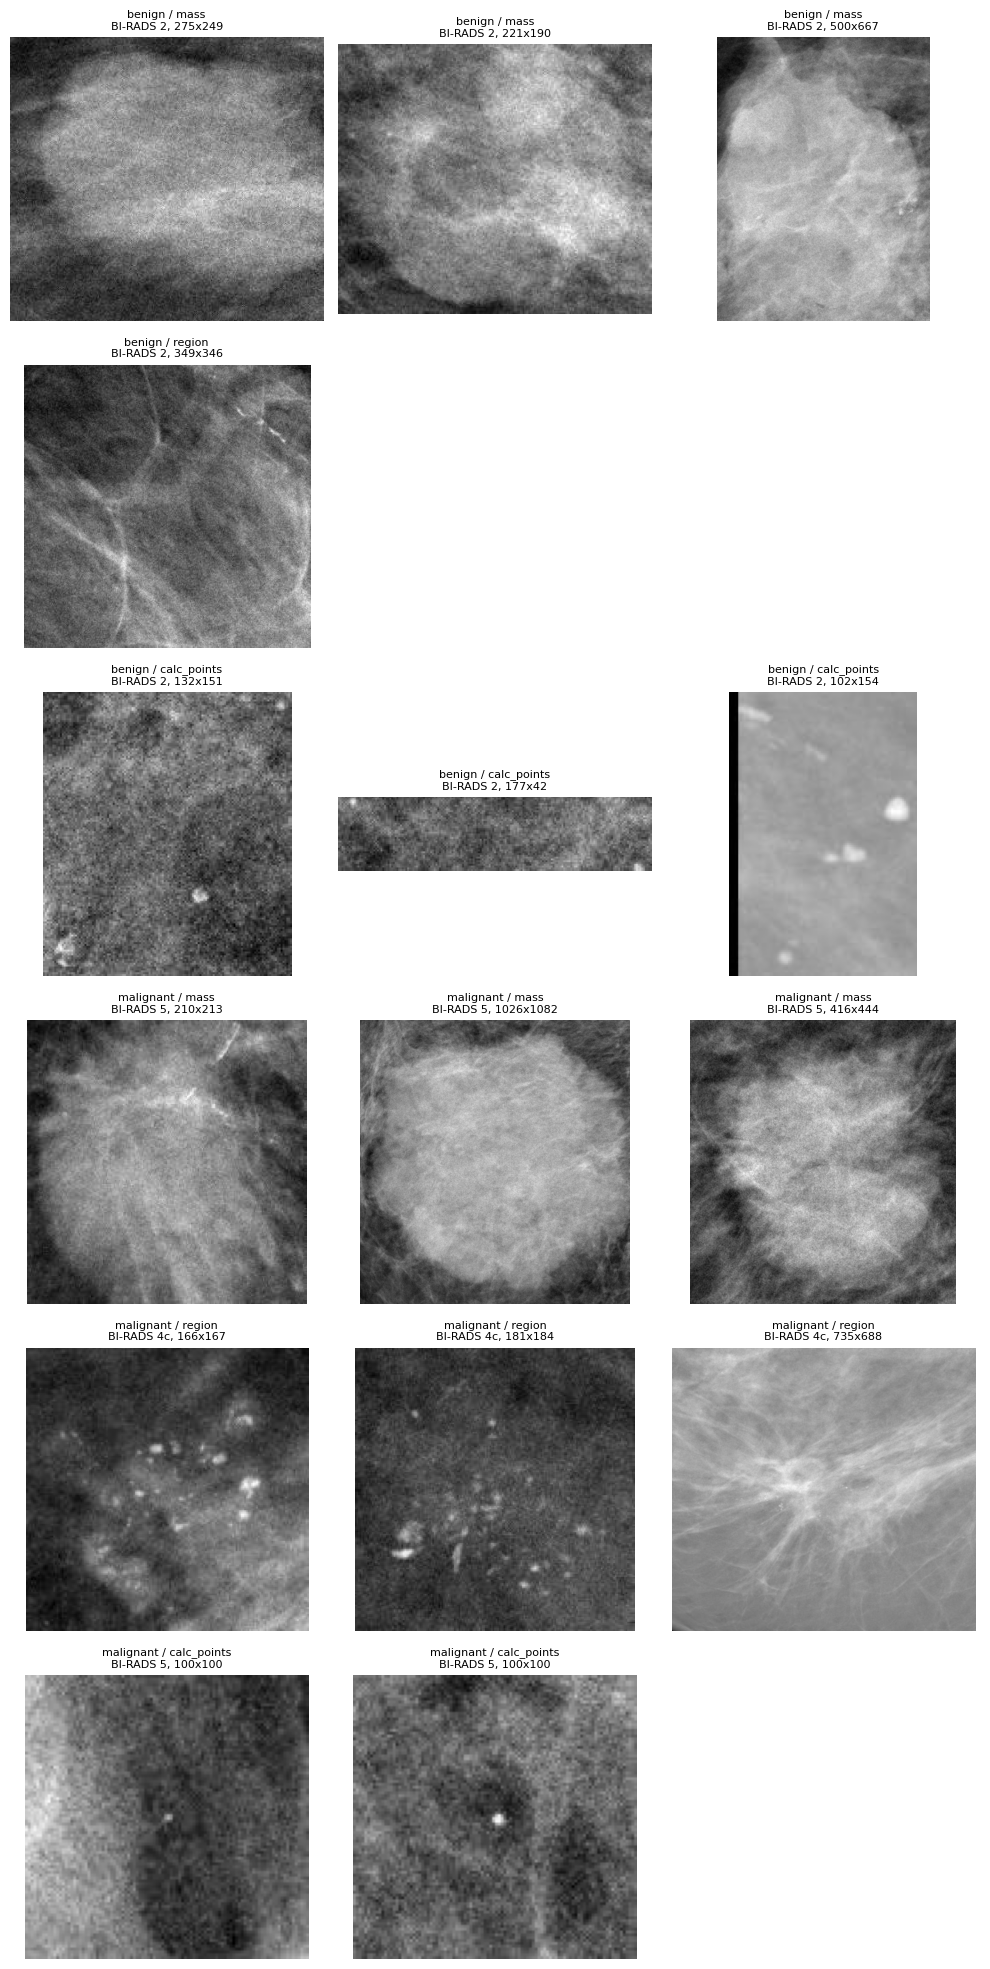

In [ ]:
# =============================================================================
# 2.9 Visual Quality Check
# =============================================================================

# Every (class, ROI type) combination present in the evaluation set
groups = [(lbl, rt) for lbl in ["benign", "malignant"] for rt in ["mass", "region", "calc_points"]
          if ((manifest_df["proxy_label"] == lbl) & (manifest_df["roi_type"] == rt)).any()]

fig, axes = plt.subplots(len(groups), 3, figsize=(10, 3.3 * len(groups)), squeeze=False)
for r, (lbl, rt) in enumerate(groups):
    sub = manifest_df[(manifest_df["proxy_label"] == lbl) & (manifest_df["roi_type"] == rt)]
    for c, (_, row) in enumerate(sub.sample(min(3, len(sub)), random_state=42).iterrows()):
        axes[r, c].imshow(Image.open(row["crop_path"]))
        axes[r, c].set_title(f"{lbl} / {rt}\nBI-RADS {row['birads']}, {row['crop_width']}x{row['crop_height']}", fontsize=8)
    for c in range(3):
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()

## 3. CBIS-DDSM Reference Results

Loads the main study's saved CBIS-DDSM test predictions for each selected model and pools the seeds exactly as the main notebook does (Section 6.2): mean probability across seeds and mean Youden threshold. The CBIS-DDSM test metadata is rebuilt from the dataset CSVs to get each case's lesion type and BI-RADS assessment. The rebuilt labels are checked against the saved predictions row by row, so a mismatch stops the notebook instead of producing wrong numbers.

These values serve as the internal reference for every comparison below.

In [ ]:
# =============================================================================
# 3. CBIS-DDSM reference results (read from the main study)
# =============================================================================
FINAL_PREDICTIONS_DIR = MAIN["final_predictions_dir"]

# Rebuild the CBIS-DDSM test set in the main notebook's order: masses then calcifications
with zipfile.ZipFile(MAIN["cbis_zip_path"]) as z:
    def _read_csv(suffix):
        matches = [m for m in z.namelist() if m.endswith(suffix)]
        assert len(matches) == 1, f"Expected one {suffix} in the zip, found {matches}"
        return pd.read_csv(io.BytesIO(z.read(matches[0])))
    cbis_test = pd.concat([_read_csv("mass_case_description_test_set.csv"),
                           _read_csv("calc_case_description_test_set.csv")], ignore_index=True)

# Pathology label, lesion type and radiologist BI-RADS for every CBIS-DDSM test case
cbis_label = (cbis_test["pathology"] == "MALIGNANT").astype(int).values
cbis_is_mass = (cbis_test["abnormality type"].astype(str).str.lower() == "mass").values
cbis_assessment = pd.to_numeric(cbis_test["assessment"], errors="coerce").values

CBIS = {}  # keyed by display name
for name in SELECTED_MODELS:
    files = sorted(glob.glob(os.path.join(FINAL_PREDICTIONS_DIR,
                                          f"{name}__final_seed*_test_predictions.npz")))
    assert files, f"No saved test predictions for {name}"
    seeds = [np.load(f) for f in files]
    # Stop if the rebuilt labels are not in the same order as the saved predictions
    for d in seeds:
        assert np.array_equal(d["y_true"].astype(int), cbis_label), (
            f"{name}: rebuilt CBIS-DDSM labels don't match the saved predictions (row order differs).")

    # Pool seeds as in the main study: mean probability and mean Youden threshold
    prob = np.mean([d["y_prob"] for d in seeds], axis=0)
    CBIS[DISPLAY[name]] = {
        "config": name,
        "n_seeds": len(seeds),
        "y_prob": prob,
        "threshold": float(np.mean([float(d["threshold"]) for d in seeds])),
        "auc_all": roc_auc_score(cbis_label, prob),
        "auc_mass": roc_auc_score(cbis_label[cbis_is_mass], prob[cbis_is_mass]),
    }

print(f"CBIS-DDSM test set: {len(cbis_label)} lesions ({cbis_is_mass.sum()} masses); labels verified.")
pd.DataFrame([{"Model": m, "Seeds": r["n_seeds"], "Pooled threshold": r["threshold"],
               "CBIS AUC (all)": r["auc_all"], "CBIS AUC (masses)": r["auc_mass"]}
              for m, r in CBIS.items()]).round(4)

CBIS-DDSM test set: 704 lesions (378 masses); labels verified.


,Model,Seeds,Pooled threshold,CBIS AUC (all),CBIS AUC (masses)
0,Baseline CNN,3,0.1081,0.6298,0.6193
1,VGG16 (Partial FT),3,0.4815,0.7486,0.7392
2,ResNet50 (Partial FT),3,0.6982,0.7574,0.7686
3,EfficientNetB0 (Partial FT),3,0.6806,0.7383,0.7402


## 4. Inference

Each model's seed checkpoints are located from the main study's search and final-training logs, and their number is checked against the saved CBIS-DDSM predictions. Every crop goes through the same preprocessing as in training: resize to the model's input size (read from the checkpoint), CLAHE with the main study's settings, then the model's own normalisation. The seed probabilities are averaged and cut at the pooled CBIS-DDSM threshold from Section 3.

In [ ]:
# =============================================================================
# 4. Inference: seed ensemble at the pooled CBIS-DDSM threshold
# =============================================================================
def preprocess_for(config_name):
    """Model-specific normalisation, chosen by architecture family."""
    if config_name.startswith("baseline"):
        return None  # has its own Rescaling layer
    if config_name.startswith("vgg16"):
        return vgg_preprocess_input
    if config_name.startswith("resnet50"):
        return resnet_preprocess_input
    if config_name.startswith("effnet"):
        return effnet_preprocess_input
    raise ValueError(f"No preprocessing rule for {config_name}")


def seed_checkpoints(config_name):
    """Winning search trial (seed 1) plus the retrained seeds, from the main study's logs."""
    best, best_auc = None, -1.0
    with open(MAIN["search_log_path"]) as f:
        for line in f:
            e = json.loads(line)
            if e["status"] == "ok" and e["config_name"] == config_name and e["val_metrics"]["auc"] > best_auc:
                best, best_auc = e, e["val_metrics"]["auc"]
    assert best is not None, f"No completed search trials for {config_name}"

   # Seed 1 = winning search trial; the other seeds come from the final-training log
    paths = [best["checkpoint"]]
    with open(MAIN["final_training_log_path"]) as f:
        for line in f:
            e = json.loads(line)
            if e["status"] == "ok" and e["config_name"] == config_name:
                paths.append(e["checkpoint"])
    # Must match the number of seeds pooled for the CBIS-DDSM reference
    expected = CBIS[DISPLAY[config_name]]["n_seeds"]
    assert len(paths) == expected, (
        f"{config_name}: found {len(paths)} checkpoints but {expected} saved CBIS-DDSM prediction files.")
    missing = [p for p in paths if not os.path.exists(p)]
    assert not missing, f"Missing checkpoints: {missing}"
    return paths


def _clahe_numpy(image_uint8):
   # Same CLAHE as training; applied to one channel, then copied to 3 (greyscale image)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID_SIZE)
    enhanced = clahe.apply(image_uint8[:, :, 0])
    return np.stack([enhanced] * 3, axis=-1).astype(np.uint8)


def make_dataset(paths, labels, image_size, preprocess):
    def _load(path, label):
        image = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
        image = tf.image.resize(image, image_size)
        # OpenCV CLAHE needs uint8 input
        image_uint8 = tf.cast(tf.clip_by_value(image, 0, 255), tf.uint8)
        # Run OpenCV CLAHE inside the tf.data pipeline
        image = tf.numpy_function(_clahe_numpy, [image_uint8], tf.uint8)
        # numpy_function loses the static shape; restore it so batching works
        image = tf.cast(tf.ensure_shape(image, (*image_size, 3)), tf.float32)
        # Model-specific normalisation (the baseline rescales inside the model)
        if preprocess is not None:
            image = preprocess(image)
        return image, label
    return (tf.data.Dataset.from_tensor_slices((paths, labels))
            .map(_load, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(32).prefetch(tf.data.AUTOTUNE))  # no shuffle: order == manifest_df order

# 1 = malignant (positive class), 0 = benign
manifest_df["true_label"] = (manifest_df["proxy_label"] == "malignant").astype(int)
y_true = manifest_df["true_label"].values

inbreast_results = {}  # keyed by display name
for name in SELECTED_MODELS:
    model_name = DISPLAY[name]
    seed_probs = []
    for ckpt in seed_checkpoints(name):
        model = tf.keras.models.load_model(ckpt)
        # Input size read from the checkpoint rather than hardcoded
        image_size = tuple(model.input_shape[1:3])
        ds = make_dataset(manifest_df["crop_path"].values, y_true, image_size, preprocess_for(name))
        seed_probs.append(model.predict(ds, verbose=0).ravel())
        # Free memory before loading the next checkpoint
        del model
        tf.keras.backend.clear_session()

    # Seed ensemble at the locked CBIS-DDSM threshold (nothing is tuned on INbreast)
    y_prob = np.mean(seed_probs, axis=0)
    threshold = CBIS[model_name]["threshold"]
    inbreast_results[model_name] = {
        "config": name, "y_prob": y_prob, "threshold": threshold,
        "y_pred": (y_prob >= threshold).astype(int), "seed_probs": seed_probs,
    }
    seed_aucs = [round(roc_auc_score(y_true, p), 3) for p in seed_probs]
    print(f"{model_name}: seed AUCs {seed_aucs}, ensemble AUC {roc_auc_score(y_true, y_prob):.3f}, "
          f"threshold {threshold:.4f}")

Baseline CNN: seed AUCs [np.float64(0.768), np.float64(0.59), np.float64(0.803)], ensemble AUC 0.736, threshold 0.1081
VGG16 (Partial FT): seed AUCs [np.float64(0.826), np.float64(0.755), np.float64(0.764)], ensemble AUC 0.787, threshold 0.4815
ResNet50 (Partial FT): seed AUCs [np.float64(0.798), np.float64(0.791), np.float64(0.806)], ensemble AUC 0.806, threshold 0.6982
EfficientNetB0 (Partial FT): seed AUCs [np.float64(0.852), np.float64(0.824), np.float64(0.841)], ensemble AUC 0.854, threshold 0.6806


## 5. External Performance

### 5.1 Point Estimates at the Locked Threshold

AUC is the primary metric because it does not depend on a threshold. Sensitivity and specificity are reported at the CBIS-DDSM threshold to show whether that operating point transfers to a new site; they are not used to rank models.

In [ ]:
# =============================================================================
# 5.1 Point estimates at the locked CBIS-DDSM threshold
# =============================================================================
rows = []
for model_name, r in inbreast_results.items():
    tn, fp, fn, tp = confusion_matrix(y_true, r["y_pred"], labels=[0, 1]).ravel()
    rows.append({
        "Model": model_name,
        "CBIS test AUC": CBIS[model_name]["auc_all"],
        "INbreast AUC": roc_auc_score(y_true, r["y_prob"]),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Predicted malignant": f"{tp + fp}/{len(y_true)}",
        "Threshold": r["threshold"],
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    })
print(f"n = {len(y_true)} images ({int(y_true.sum())} malignant) "
      f"from {manifest_df['patient'].nunique()} patients")
inbreast_metrics_df = pd.DataFrame(rows).round(4)
inbreast_metrics_df

n = 293 images (76 malignant) from 88 patients


,Model,CBIS test AUC,INbreast AUC,Sensitivity,Specificity,Predicted malignant,Threshold,TN,FP,FN,TP
0,Baseline CNN,0.6298,0.7363,0.5132,0.7972,83/293,0.1081,173,44,37,39
1,VGG16 (Partial FT),0.7486,0.7872,0.7895,0.6037,146/293,0.4815,131,86,16,60
2,ResNet50 (Partial FT),0.7574,0.8056,0.7500,0.6498,133/293,0.6982,141,76,19,57
3,EfficientNetB0 (Partial FT),0.7383,0.8541,0.7105,0.8203,93/293,0.6806,178,39,22,54


### 5.2 Calibration Shift

A model can rank cases well (good AUC) even when its predicted probabilities have shifted on the new dataset, which moves the CBIS-DDSM threshold to the wrong place. The histograms and Brier scores show this shift.

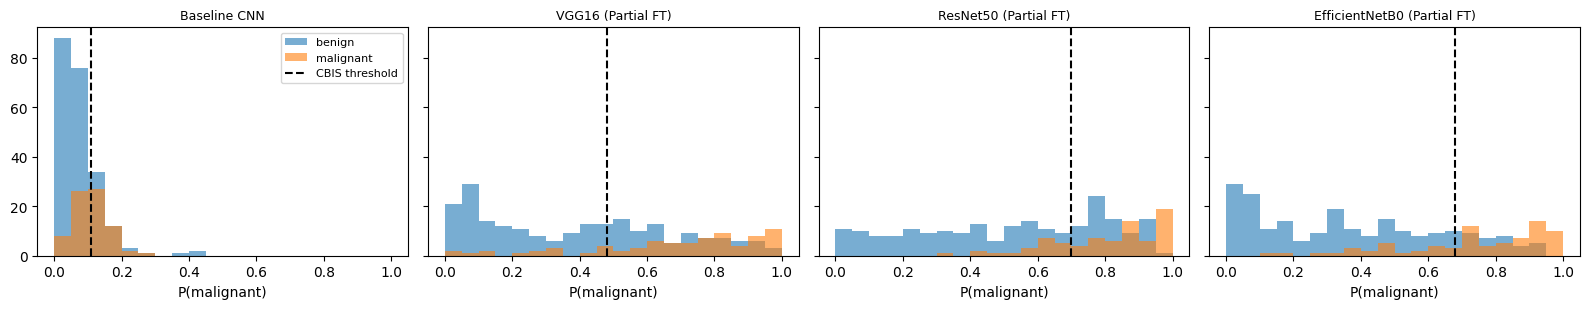

,Model,Mean P | benign,Mean P | malignant,Observed malignant rate,Mean predicted P,Brier
0,Baseline CNN,0.0767,0.1120,0.2594,0.0858,0.2121
1,VGG16 (Partial FT),0.3893,0.6922,0.2594,0.4679,0.2115
2,ResNet50 (Partial FT),0.5230,0.8061,0.2594,0.5964,0.2759
3,EfficientNetB0 (Partial FT),0.3663,0.7377,0.2594,0.4626,0.1827


In [ ]:
# =============================================================================
# 5.2 Calibration Shift
# =============================================================================

fig, axes = plt.subplots(1, len(inbreast_results), figsize=(4 * len(inbreast_results), 3.2), sharey=True)
for ax, (model_name, r) in zip(axes, inbreast_results.items()):
    p = r["y_prob"]
    bins = np.linspace(0, 1, 21)
    ax.hist(p[y_true == 0], bins=bins, alpha=0.6, label="benign")
    ax.hist(p[y_true == 1], bins=bins, alpha=0.6, label="malignant")
    ax.axvline(r["threshold"], color="k", linestyle="--", label="CBIS threshold")
    ax.set_title(model_name, fontsize=9)
    ax.set_xlabel("P(malignant)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Mean predicted probability vs observed malignant rate; Brier = mean squared error of the probabilities
cal_rows = []
for model_name, r in inbreast_results.items():
    p = r["y_prob"]
    cal_rows.append({
        "Model": model_name,
        "Mean P | benign": p[y_true == 0].mean(),
        "Mean P | malignant": p[y_true == 1].mean(),
        "Observed malignant rate": y_true.mean(),
        "Mean predicted P": p.mean(),
        "Brier": brier_score_loss(y_true, p),
    })
pd.DataFrame(cal_rows).round(4)

### 5.3 Patient-Level Bootstrap Confidence Intervals

Patients are resampled with replacement, keeping all of each patient's images together, since views of the same breast are not independent. The same resamples are reused for every model, which makes the paired comparison in 5.4 valid.

In [ ]:
# =============================================================================
# 5.3 Patient-Level Bootstrap CIs
# =============================================================================

# Resample patients (not images), keeping each patient's images togethe
rng = np.random.default_rng(RANDOM_SEED)

patients = manifest_df["patient"].values
unique_patients = np.unique(patients)
# Row positions of each patient's images
patient_to_idx = {p: np.where(patients == p)[0] for p in unique_patients}

# Resamples are drawn once and reused for every model (paired comparison in 5.4)
boot_indices = []
while len(boot_indices) < N_BOOTSTRAP:
    chosen = rng.choice(unique_patients, size=len(unique_patients), replace=True)
    idx = np.concatenate([patient_to_idx[p] for p in chosen])
    if len(np.unique(y_true[idx])) == 2:  # need both classes for AUC
        boot_indices.append(idx)


def _sens_spec(yt, yp):
    tp = np.sum((yp == 1) & (yt == 1)); fn = np.sum((yp == 0) & (yt == 1))
    tn = np.sum((yp == 0) & (yt == 0)); fp = np.sum((yp == 1) & (yt == 0))
    return tp / (tp + fn), tn / (tn + fp)

# Percentile 95% confidence interval
def _ci(values):
    return np.percentile(values, 2.5), np.percentile(values, 97.5)


boot_aucs = {}
ci_rows = []
for model_name, r in inbreast_results.items():
    aucs, sens, spec = [], [], []
    for idx in boot_indices:
        yt = y_true[idx]
        aucs.append(roc_auc_score(yt, r["y_prob"][idx]))
        s, sp = _sens_spec(yt, r["y_pred"][idx])
        sens.append(s); spec.append(sp)
    boot_aucs[model_name] = np.array(aucs)

    point_sens, point_spec = _sens_spec(y_true, r["y_pred"])
    a_lo, a_hi = _ci(aucs); s_lo, s_hi = _ci(sens); p_lo, p_hi = _ci(spec)
    ci_rows.append({
        "Model": model_name,
        "AUC": f"{roc_auc_score(y_true, r['y_prob']):.3f} [{a_lo:.3f}, {a_hi:.3f}]",
        "Sensitivity": f"{point_sens:.3f} [{s_lo:.3f}, {s_hi:.3f}]",
        "Specificity": f"{point_spec:.3f} [{p_lo:.3f}, {p_hi:.3f}]",
    })

print(f"Section 5.5: INbreast, point estimate [95% patient-level bootstrap CI], "
      f"{N_BOOTSTRAP} resamples of {len(unique_patients)} patients ({len(y_true)} images)")
inbreast_ci_df = pd.DataFrame(ci_rows)
inbreast_ci_df

Section 5.5: INbreast, point estimate [95% patient-level bootstrap CI], 2000 resamples of 88 patients (293 images)


,Model,AUC,Sensitivity,Specificity
0,Baseline CNN,"0.736 [0.657, 0.812]","0.513 [0.385, 0.653]","0.797 [0.723, 0.866]"
1,VGG16 (Partial FT),"0.787 [0.714, 0.856]","0.789 [0.667, 0.893]","0.604 [0.516, 0.687]"
2,ResNet50 (Partial FT),"0.806 [0.742, 0.867]","0.750 [0.634, 0.851]","0.650 [0.574, 0.729]"
3,EfficientNetB0 (Partial FT),"0.854 [0.799, 0.905]","0.711 [0.595, 0.823]","0.820 [0.761, 0.876]"


### 5.4 Paired Model Comparison

Bootstrap distribution of AUC differences between each pair of models, with Holm correction for multiple comparisons. A model is only described as better if the corrected p-value supports it.

In [ ]:
# =============================================================================
# 5.4 Paired Model Comparison
# =============================================================================

from itertools import combinations

pair_rows = []
for a, b in combinations(inbreast_results.keys(), 2):
    # Paired: both models scored on the same resamples
    diff = boot_aucs[a] - boot_aucs[b]
    point = roc_auc_score(y_true, inbreast_results[a]["y_prob"]) - roc_auc_score(y_true, inbreast_results[b]["y_prob"])
    # Two-sided bootstrap p-value: how often the AUC difference crosses zero
    p = min(1.0, 2 * min((diff <= 0).mean(), (diff >= 0).mean()))
    lo, hi = _ci(diff)
    pair_rows.append({"Model A": a, "Model B": b, "AUC A - B": round(point, 4),
                      "95% CI": f"[{lo:.3f}, {hi:.3f}]", "p (raw)": p})

pair_df = pd.DataFrame(pair_rows).sort_values("p (raw)").reset_index(drop=True)
m = len(pair_df)
holm = np.maximum.accumulate([(m - i) * p for i, p in enumerate(pair_df["p (raw)"])])
pair_df["p (Holm)"] = np.minimum(holm, 1.0).round(4)
pair_df

,Model A,Model B,AUC A - B,95% CI,p (raw),p (Holm)
0,VGG16 (Partial FT),EfficientNetB0 (Partial FT),-0.0669,"[-0.114, -0.020]",0.001,0.006
1,Baseline CNN,EfficientNetB0 (Partial FT),-0.1178,"[-0.196, -0.040]",0.005,0.025
2,ResNet50 (Partial FT),EfficientNetB0 (Partial FT),-0.0484,"[-0.092, -0.007]",0.025,0.100
3,Baseline CNN,ResNet50 (Partial FT),-0.0693,"[-0.153, 0.011]",0.095,0.285
4,Baseline CNN,VGG16 (Partial FT),-0.0509,"[-0.142, 0.042]",0.260,0.520
5,VGG16 (Partial FT),ResNet50 (Partial FT),-0.0184,"[-0.057, 0.019]",0.317,0.520


## 6. Robustness Checks

### 6.1 Shortcut Checks

Tests whether the classes can be separated without any model, using lesion type or crop size alone. An AUC far from 0.5 for either trivial predictor means the overall INbreast AUC is partly confounded.
Crop area alone is partly predictive because of the crop procedure: benign calcification crops mostly sit at the 100 px minimum box, whereas malignant lesions are mostly larger mass crops.

In [ ]:
# =============================================================================
# 6.1 Shortcut Checks
# =============================================================================

print("ROI type by class:")
print(pd.crosstab(manifest_df["roi_type"], manifest_df["proxy_label"], margins=True))

# Trivial predictors: AUC far from 0.5 means the label is confounded with them
crop_area = (manifest_df["crop_width"] * manifest_df["crop_height"]).values
shortcut_rows = [
    {"Predictor": "Crop area (px^2)", "AUC": roc_auc_score(y_true, crop_area)},
    {"Predictor": "Is mass ROI (0/1)", "AUC": roc_auc_score(y_true, (manifest_df["roi_type"] == "mass").astype(int))},
]
print("\nAUC from trivial predictors (0.5 = no signal; far from 0.5 in either direction = confound):")
print(pd.DataFrame(shortcut_rows).round(3).to_string(index=False))

print("\nMedian crop size by class and ROI type:")
print(manifest_df.assign(crop_area=crop_area)
      .groupby(["proxy_label", "roi_type"])["crop_area"].median().round(0))

ROI type by class:
proxy_label  benign  malignant  All
roi_type                           
calc_points     194          2  196
mass             22         62   84
region            1         12   13
All             217         76  293

AUC from trivial predictors (0.5 = no signal; far from 0.5 in either direction = confound):
        Predictor   AUC
 Crop area (px^2) 0.726
Is mass ROI (0/1) 0.857

Median crop size by class and ROI type:
proxy_label  roi_type   
benign       calc_points     10090.0
             mass            48250.0
             region         120754.0
malignant    calc_points     10000.0
             mass           129892.0
             region         142116.0
Name: crop_area, dtype: float64


### 6.2 AUC by ROI Type

AUC within each lesion type, which removes the lesion-type shortcut. Strata with fewer than 5 cases in either class are shown as counts only.

In [ ]:
# =============================================================================
# 6.2 AUC by ROI Type
# =============================================================================


# AUC is unreliable with fewer than 5 cases in a class
MIN_PER_CLASS = 5
strat_rows = []
for rt, sub in manifest_df.groupby("roi_type"):
    idx = sub.index.values
    yt = y_true[idx]
    n_ben, n_mal = int((yt == 0).sum()), int((yt == 1).sum())
    row = {"ROI type": rt, "Benign": n_ben, "Malignant": n_mal}
    for model_name, r in inbreast_results.items():
        row[model_name] = (round(roc_auc_score(yt, r["y_prob"][idx]), 3)
                           if min(n_ben, n_mal) >= MIN_PER_CLASS else "too few")
    strat_rows.append(row)
pd.DataFrame(strat_rows)

,ROI type,Benign,Malignant,Baseline CNN,VGG16 (Partial FT),ResNet50 (Partial FT),EfficientNetB0 (Partial FT)
0,calc_points,194,2,too few,too few,too few,too few
1,mass,22,62,0.73,0.825,0.879,0.866
2,region,1,12,too few,too few,too few,too few


### 6.3 One View per Breast

Keeps one image per breast (CC where available), so each lesion is counted once. A large change here would mean duplicate views were inflating the main result.

In [ ]:
# =============================================================================
# 6.3 One View per Breast
# =============================================================================


# Prefer CC, then MLO, then any other view
view_rank = manifest_df["view"].map({"CC": 0, "MLO": 1}).fillna(2)
# Keep the first-ranked image of each breast
one_view_idx = (manifest_df.assign(_r=view_rank)
                .sort_values(["breast", "_r"])
                .groupby("breast").head(1).index.values)

yt1 = y_true[one_view_idx]
print(f"One-view subset: {len(one_view_idx)} images "
      f"({int(yt1.sum())} malignant, {int((yt1 == 0).sum())} benign)")

ov_rows = []
for model_name, r in inbreast_results.items():
    ov_rows.append({"Model": model_name,
                    "AUC (all views)": roc_auc_score(y_true, r["y_prob"]),
                    "AUC (one view per breast)": roc_auc_score(yt1, r["y_prob"][one_view_idx])})
pd.DataFrame(ov_rows).round(4)

One-view subset: 139 images (39 malignant, 100 benign)


,Model,AUC (all views),AUC (one view per breast)
0,Baseline CNN,0.7363,0.7428
1,VGG16 (Partial FT),0.7872,0.8213
2,ResNet50 (Partial FT),0.8056,0.8364
3,EfficientNetB0 (Partial FT),0.8541,0.8728


### 6.4 Mass-Only External Validation (Primary External Result)

Because lesion type alone predicts the INbreast proxy label (Section 6.1), the all-lesion AUC is confounded. Within masses the shortcut is unavailable, so this subset is the primary external result. The CBIS-DDSM mass AUC comes from Section 3.

In [ ]:
# =============================================================================
# 6.4 Mass-only external validation
# =============================================================================
# Mass crops only: lesion type can no longer act as a shortcut
mass_idx = manifest_df.index[manifest_df["roi_type"] == "mass"].values
ym = y_true[mass_idx]
mass_patients = manifest_df.loc[mass_idx, "patient"].values
uniq_mp = np.unique(mass_patients)
# Patient-level bootstrap restricted to the mass subset
mp_to_idx = {p: np.where(mass_patients == p)[0] for p in uniq_mp}
print(f"Mass subset: {len(mass_idx)} images ({int(ym.sum())} malignant, "
      f"{int((ym == 0).sum())} benign) from {len(uniq_mp)} patients")


# Separate generator with the same seed, so the mass resamples are reproducible
rng_m = np.random.default_rng(RANDOM_SEED)
mass_boot = []
while len(mass_boot) < N_BOOTSTRAP:
    chosen = rng_m.choice(uniq_mp, size=len(uniq_mp), replace=True)
    idx = np.concatenate([mp_to_idx[p] for p in chosen])
    if len(np.unique(ym[idx])) == 2:
        mass_boot.append(idx)

INBREAST_MASS_AUC, mass_boot_aucs, rows = {}, {}, []
for model_name, r in inbreast_results.items():
    pm = r["y_prob"][mass_idx]
    INBREAST_MASS_AUC[model_name] = roc_auc_score(ym, pm)
    mass_boot_aucs[model_name] = np.array([roc_auc_score(ym[i], pm[i]) for i in mass_boot])
    lo, hi = _ci(mass_boot_aucs[model_name])
    rows.append({"Model": model_name,
                 "CBIS AUC (masses)": round(CBIS[model_name]["auc_mass"], 3),
                 "INbreast AUC (masses) [95% CI]": f"{INBREAST_MASS_AUC[model_name]:.3f} [{lo:.3f}, {hi:.3f}]"})
display(pd.DataFrame(rows))

pair_rows = []
for a, b in combinations(inbreast_results.keys(), 2):
    # Paired bootstrap difference, Holm-corrected below (same method as 5.4)
    diff = mass_boot_aucs[a] - mass_boot_aucs[b]
    lo, hi = _ci(diff)
    pair_rows.append({"Model A": a, "Model B": b,
                      "AUC A - B": round(INBREAST_MASS_AUC[a] - INBREAST_MASS_AUC[b], 4),
                      "95% CI": f"[{lo:.3f}, {hi:.3f}]",
                      "p (raw)": min(1.0, 2 * min((diff <= 0).mean(), (diff >= 0).mean()))})
mass_pair_df = pd.DataFrame(pair_rows).sort_values("p (raw)").reset_index(drop=True)
m = len(mass_pair_df)
mass_pair_df["p (Holm)"] = np.minimum(np.maximum.accumulate(
    [(m - i) * p for i, p in enumerate(mass_pair_df["p (raw)"])]), 1.0).round(4)
mass_pair_df

Mass subset: 84 images (62 malignant, 22 benign) from 40 patients


,Model,CBIS AUC (masses),INbreast AUC (masses) [95% CI]
0,Baseline CNN,0.619,"0.730 [0.509, 0.951]"
1,VGG16 (Partial FT),0.739,"0.825 [0.688, 0.931]"
2,ResNet50 (Partial FT),0.769,"0.879 [0.726, 0.973]"
3,EfficientNetB0 (Partial FT),0.740,"0.866 [0.718, 0.963]"


,Model A,Model B,AUC A - B,95% CI,p (raw),p (Holm)
0,Baseline CNN,ResNet50 (Partial FT),-0.1488,"[-0.338, 0.032]",0.125,0.750
1,VGG16 (Partial FT),ResNet50 (Partial FT),-0.0543,"[-0.137, 0.020]",0.152,0.760
2,Baseline CNN,EfficientNetB0 (Partial FT),-0.1356,"[-0.324, 0.049]",0.161,0.760
3,VGG16 (Partial FT),EfficientNetB0 (Partial FT),-0.0411,"[-0.146, 0.041]",0.331,0.993
4,Baseline CNN,VGG16 (Partial FT),-0.0946,"[-0.319, 0.142]",0.452,0.993
5,ResNet50 (Partial FT),EfficientNetB0 (Partial FT),0.0132,"[-0.049, 0.068]",0.698,0.993


### 6.5 Case-Mix Check

Tests whether the INbreast mass AUC is higher than the CBIS-DDSM mass AUC because the INbreast cases are easier. The INbreast labels keep only BI-RADS extremes, so the CBIS-DDSM test masses are restricted the same way. The label is still pathology; the radiologist's BI-RADS assessment only decides which cases are kept. BI-RADS 0 (incomplete workup) is excluded from every subset except "All masses".

| Subset | Benign | Malignant | Purpose |
|---|---|---|---|
| Easy | BI-RADS 1–3 | BI-RADS 5 | Mimics the INbreast selection |
| Easy, looser | BI-RADS 1–4 | BI-RADS 5 | Robustness check with more benign cases |
| Hard | BI-RADS ≥4 | BI-RADS 1–4 | Diagnostically ambiguous cases |

If the easy-subset AUC reaches the INbreast level, the higher external AUC reflects case mix rather than better generalisation.

In [ ]:
# =============================================================================
# 6.5 Case-mix check: CBIS-DDSM masses restricted to BI-RADS extremes
# =============================================================================
lab, asmt, is_mass = cbis_label, cbis_assessment, cbis_is_mass

print("CBIS-DDSM test masses, BI-RADS assessment by label:")
print(pd.crosstab(asmt[is_mass], lab[is_mass],
                  rownames=["assessment"], colnames=["label (1=malignant)"]), "\n")

EASY, EASY_LOOSE, HARD = ("Easy (benign 1-3 vs malignant 5)",
                          "Easy, looser (benign 1-4 vs malignant 5)",
                          "Hard (benign >=4 vs malignant 1-4)")

# Label stays pathology; BI-RADS only selects cases (assessment 0 falls outside every range)
CASEMIX_SUBSETS = {
    "All masses": is_mass,
    EASY: is_mass & (((lab == 0) & (asmt >= 1) & (asmt <= 3)) | ((lab == 1) & (asmt == 5))),
    EASY_LOOSE: is_mass & (((lab == 0) & (asmt >= 1) & (asmt <= 4)) | ((lab == 1) & (asmt == 5))),
    HARD: is_mass & (((lab == 0) & (asmt >= 4)) | ((lab == 1) & (asmt >= 1) & (asmt <= 4))),
}


CASEMIX, rows = {}, []
for model_name in inbreast_results:
    p = CBIS[model_name]["y_prob"]
    CASEMIX[model_name] = {}
    row = {"Model": model_name}
    for subset, mask in CASEMIX_SUBSETS.items():
        n_b, n_m = int((lab[mask] == 0).sum()), int((lab[mask] == 1).sum())
        # AUC only when both classes have at least 5 cases
        auc = roc_auc_score(lab[mask], p[mask]) if min(n_b, n_m) >= 5 else np.nan
        CASEMIX[model_name][subset] = auc
        row[f"{subset} [{n_b}B/{n_m}M]"] = round(auc, 3)
    row["INbreast masses (6.4)"] = round(INBREAST_MASS_AUC[model_name], 3)
    rows.append(row)
pd.DataFrame(rows)

CBIS-DDSM test masses, BI-RADS assessment by label:
label (1=malignant)    0   1
assessment                  
0                     30   3
1                      0   2
2                     13   1
3                     81   4
4                    102  67
5                      5  70 



,Model,All masses [231B/147M],Easy (benign 1-3 vs malignant 5) [94B/70M],"Easy, looser (benign 1-4 vs malignant 5) [196B/70M]",Hard (benign >=4 vs malignant 1-4) [107B/74M],INbreast masses (6.4)
0,Baseline CNN,0.619,0.692,0.740,0.564,0.730
1,VGG16 (Partial FT),0.739,0.899,0.876,0.590,0.825
2,ResNet50 (Partial FT),0.769,0.924,0.901,0.597,0.879
3,EfficientNetB0 (Partial FT),0.740,0.914,0.889,0.572,0.866


## 7. Summary

All headline numbers in one table, generated from the results above and saved to Drive for the report.

In [ ]:
# =============================================================================
# 7. Summary table
# =============================================================================
# One row per model: internal vs external AUC (all lesions, masses) plus case-mix references
rows = []
for model_name in inbreast_results:
    lo, hi = _ci(boot_aucs[model_name])
    mlo, mhi = _ci(mass_boot_aucs[model_name])
    rows.append({
        "Model": model_name,
        "CBIS AUC (all)": round(CBIS[model_name]["auc_all"], 3),
        "INbreast AUC (all) [95% CI]": f"{roc_auc_score(y_true, inbreast_results[model_name]['y_prob']):.3f} [{lo:.3f}, {hi:.3f}]",
        "CBIS AUC (masses)": round(CBIS[model_name]["auc_mass"], 3),
        "INbreast AUC (masses) [95% CI]": f"{INBREAST_MASS_AUC[model_name]:.3f} [{mlo:.3f}, {mhi:.3f}]",
        "CBIS AUC (easy masses)": round(CASEMIX[model_name][EASY], 3),
        "CBIS AUC (hard masses)": round(CASEMIX[model_name][HARD], 3),
    })
summary_df = pd.DataFrame(rows)

print("Shortcut predictors (Section 6.1):")
for r in shortcut_rows:
    print(f"  {r['Predictor']}: AUC {r['AUC']:.3f}")

# Saved to Drive for the report
summary_path = os.path.join(DRIVE_DIR, "external_validation_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved to {summary_path}")
summary_df

Shortcut predictors (Section 6.1):
  Crop area (px^2): AUC 0.726
  Is mass ROI (0/1): AUC 0.857

Saved to /content/drive/MyDrive/random_search_full/external_validation_summary.csv


,Model,CBIS AUC (all),INbreast AUC (all) [95% CI],CBIS AUC (masses),INbreast AUC (masses) [95% CI],CBIS AUC (easy masses),CBIS AUC (hard masses)
0,Baseline CNN,0.630,"0.736 [0.657, 0.812]",0.619,"0.730 [0.509, 0.951]",0.692,0.564
1,VGG16 (Partial FT),0.749,"0.787 [0.714, 0.856]",0.739,"0.825 [0.688, 0.931]",0.899,0.590
2,ResNet50 (Partial FT),0.757,"0.806 [0.742, 0.867]",0.769,"0.879 [0.726, 0.973]",0.924,0.597
3,EfficientNetB0 (Partial FT),0.738,"0.854 [0.799, 0.905]",0.740,"0.866 [0.718, 0.963]",0.914,0.572


### Conclusions

- **All lesions.** The overall INbreast AUC is confounded by lesion type (Section 6.1): benign cases are mostly calcifications and malignant cases mostly masses, so it is not interpreted as generalisation performance.
- **Masses (primary result).** Discrimination is retained on INbreast masses (Section 6.4), but the benign mass group is small, so confidence intervals are wide.
- **Why external AUC is higher.**  Restricting CBIS-DDSM to the same BI-RADS extremes raises internal AUC to the INbreast level, while ambiguous cases fall towards chance (Section 6.5). The higher external AUC reflects an easier case mix, not better generalisation, consistent with Yu et al. (2022).
- **Thresholds.** The CBIS-DDSM operating points do not transfer (Section 5.2), so use at a new site would need local threshold recalibration.
- **Limitations.** Labels are a BI-RADS proxy, not pathology, and hard cases (BI-RADS 3/4a/4b) cannot be evaluated on INbreast.